Typed Dictonary is a special Dictonary where what will the data type in our key value pair 

In [1]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict

/Users/vishwas/Desktop/Gen_Ai/.venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
# Define State
class BMIState(TypedDict):
    weight_kg : float
    height_m : float
    bmi : float
    catagory : str

In [3]:
def calculate_bmi(State : BMIState)-> BMIState:
    weight = State['weight_kg']
    height = State['height_m']
    bmi = weight / (height ** 2)
    State['bmi'] = round(bmi,2)
    return State

In [4]:
def label_bmi(State : BMIState) -> BMIState:
    bmi = State['bmi']
    if bmi < 18.5:
        State['catagory'] = 'Underweight'
    elif 18.5 <= bmi < 25:
        State['catagory'] = 'Normal weight'
    elif 25 <= bmi < 30:
        State['catagory'] = 'Overweight'
    else:
        State['catagory'] = 'Obese'
    return State

When building Object we pass our state Here 

In [5]:
# Define The Graph
graph = StateGraph(BMIState)

# Add Node to the Graph
graph.add_node('Calculate BMI', calculate_bmi)
graph.add_node('label_bmi' , label_bmi)

# Add adges to the graph
graph.add_edge(START , 'Calculate BMI')
graph.add_edge('Calculate BMI' , 'label_bmi')
graph.add_edge('label_bmi' , END)
# After both Compile the Graph
workflow = graph.compile()


In [6]:
# Execute the Graph
initial_state = {'weight_kg': 70, 'height_m': 1.73}
final_state = workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 70, 'height_m': 1.73, 'bmi': 23.39, 'catagory': 'Normal weight'}


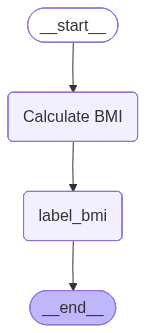

In [16]:
from IPython.display import Image
Image (workflow.get_graph() .draw_mermaid_png())